# TurtleBot Navigation Performance Analysis

Objective
- Evaluate navigation performance across Rooms, Circle, Hallways, and Large Rooms using run logs and maps.

Inputs
- CSV logs: ground truth (position.x/y), estimated pose (pose.pose.position.x/y), timestamps.
- Maps: YAML (resolution, origin) + PGM image per scenario.

Primary Metrics
- Trajectory alignment (GT vs Estimate per run)
- Final distance-to-goal (meters)
- Pose distribution diagnostics (KDE)

How to Run
- Ensure CSVs are in `data/sample_dataset_csv/` and maps in `data/sample_dataset/...`.
- Install deps if needed: `pip install pandas numpy matplotlib seaborn pyyaml`.
- Run cells from 1 to the end.


# 1. Importing Libraries

In [105]:

import pandas as pd       # for handling datasets (tables)
import numpy as np        # for numerical operations
import matplotlib.pyplot as plt   # for visualizations
import seaborn as sns     # for nicer statistical plots
import matplotlib.image as mpimg
import yaml
import os

# Make plots look better
plt.style.use('seaborn-v0_8')
sns.set_palette('viridis')

print("Libraries imported successfully!")

Libraries imported successfully!


# 2. Define Dataset Class and Configuration


In [106]:

# Path to CSV datasets
DATASET_CSV_PATH = "data/sample_dataset_csv"

# Class to hold dataset information
class DatasetRos:
    def __init__(self, scenario, run_n, csv_file):
        self.scenario = scenario
        self.run_n = run_n
        self.csv_file = csv_file
        self.df = pd.read_csv(
            csv_file,
            skiprows=2,       
            sep=',',           
            low_memory=False
        )
        # Add run_id for tracking
        self.df['run_id'] = f"{scenario}_{run_n}"
        self.df['scenario'] = scenario

# Map scenario information
scenario_config = {
    "rooms-generated-3954-p1-o0-box-sd000n005": {
        "map_yaml": "data/sample_dataset/rooms-generated-3954-p1-o0-box-sd000n005/0/maps/rooms.yaml",
        "map_pgm": "data/sample_dataset/rooms-generated-3954-p1-o0-box-sd000n005/0/maps/rooms.pgm",
        "start": (-0.5976, 0.9705),
        "goal": (-6.1695, 7.6153),
        "name": "Rooms"
    },
    "circle-generated-p1-o4-box-sd000n000": {
        "map_yaml": "data/sample_dataset/circle-generated-p1-o4-box-sd000n000/0/maps/circle.yaml",
        "map_pgm": "data/sample_dataset/circle-generated-p1-o4-box-sd000n000/0/maps/circle.pgm",
        "start": (6.678927854430759, 8.737886371201855),
        "goal": (11.743150510000254, 5.127016769828601),
        "name": "Circle"
    },
    "hallways-generated-2542-p2-o4-box-sd010n005": {
        "map_yaml": "data/sample_dataset/hallways-generated-2542-p2-o4-box-sd010n005/0/maps/hallways.yaml",
        "map_pgm": "data/sample_dataset/hallways-generated-2542-p2-o4-box-sd010n005/0/maps/hallways.pgm",
        "start": (4.008009015415047, 4.777931803065092),  
        "goal": (5.289100174604297, -5.01465604465875),  
        "name": "Hallways"
    },
    "large-room-generated-7060-p1-o4-box-sd000n000": {
        "map_yaml": "data/sample_dataset/large-room-generated-7060-p1-o4-box-sd000n000/0/maps/large_room.yaml",
        "map_pgm": "data/sample_dataset/large-room-generated-7060-p1-o4-box-sd000n000/0/maps/large_room.pgm",
        "start": (-2.3061061526567754, 1.8248179468880812),  
        "goal": (2.7058972685930334, -1.9699846477626535),  
        "name": "Large Rooms"
    }
}

print(" Dataset class and configuration defined!")

 Dataset class and configuration defined!


# 3. Load All Datasets Automatically

In [107]:

dataset = []

for csv_file in os.listdir(DATASET_CSV_PATH):
    if csv_file.endswith(".csv"):
        full_path = os.path.join(DATASET_CSV_PATH, csv_file)
        
        # Extract scenario and run number from filename
        name = csv_file[:-4]  # Remove .csv
        name_parts = name.rsplit('-', 1)
        scenario = name_parts[0]
        run_n = int(name_parts[1])
        
        # Group by scenarios
        is_new_scenario = True
        for scenario_group in dataset:
            if scenario_group[0].scenario == scenario:
                scenario_group.append(DatasetRos(scenario, run_n, full_path))
                is_new_scenario = False
                break
        
        if is_new_scenario:
            scenario_group = [DatasetRos(scenario, run_n, full_path)]
            dataset.append(scenario_group)

# Sort scenarios and runs for consistent ordering
for scenario_group in dataset:
    scenario_group.sort(key=lambda x: x.run_n)

print(f" Loaded {len(dataset)} scenarios:")
for scenario_group in dataset:
    print(f"   - {scenario_group[0].scenario}: {len(scenario_group)} runs")

 Loaded 4 scenarios:
   - rooms-generated-3954-p1-o0-box-sd000n005: 3 runs
   - large-room-generated-7060-p1-o4-box-sd000n000: 3 runs
   - circle-generated-p1-o4-box-sd000n000: 3 runs
   - hallways-generated-2542-p2-o4-box-sd010n005: 3 runs


# 4. Define Helper Functions

In [108]:


def to_pixel(x, y, resolution, origin, map_image):
    """Convert world coordinates to pixel coordinates"""
    x_pix = (x - origin[0]) / resolution
    y_pix = map_image.shape[0] - ((y - origin[1]) / resolution)
    return x_pix, y_pix

def get_scenario_config(scenario_name):
    """Get configuration for a scenario"""
    for key, config in scenario_config.items():
        if scenario_name.startswith(key):
            return config
    return None

def clean_dataframe(df):
    """Clean and prepare dataframe"""
    important_cols = [
        'timestamp',
        'pose.pose.position.x', 'pose.pose.position.y',
        'position.x', 'position.y',
        'run_id', 'scenario'
    ]
    
    # Filter to important columns (only those that exist)
    available_cols = [col for col in important_cols if col in df.columns]
    df_clean = df[available_cols].copy()
    
    # Drop rows with all NaN position values
    df_clean = df_clean.dropna(subset=[
        'position.x', 'position.y',
        'pose.pose.position.x', 'pose.pose.position.y'
    ], how='all')
    
    return df_clean

# --- Plotting helpers ---
def plot_run_trajectory(run_data, title, color='C0'):
    plt.figure(figsize=(6, 6))
    plt.plot(run_data['position.x'], run_data['position.y'],
             color='black', linewidth=2, label='Ground Truth')
    plt.scatter(run_data['pose.pose.position.x'], run_data['pose.pose.position.y'],
                color=color, s=8, alpha=0.6, label='Estimated')
    plt.title(title)
    plt.xlabel("X Position (m)")
    plt.ylabel("Y Position (m)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_kde_distributions(df_clean, title_prefix):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.kdeplot(df_clean['position.x'], label='Ground Truth X', fill=True)
    sns.kdeplot(df_clean['pose.pose.position.x'], label='Estimated X', fill=True)
    plt.title(f"{title_prefix} - X Position Distribution")
    plt.xlabel("X Position (m)")
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    sns.kdeplot(df_clean['position.y'], label='Ground Truth Y', fill=True)
    sns.kdeplot(df_clean['pose.pose.position.y'], label='Estimated Y', fill=True)
    plt.title(f"{title_prefix} - Y Position Distribution")
    plt.xlabel("Y Position (m)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print(" Helper functions defined!")

 Helper functions defined!


# 5. Analyze All Scenarios

<ipython-input-109-2d0bb6d16b20>:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10')



--- Rooms (rooms-generated-3954-p1-o0-box-sd000n005) ---
Missing (pose GT/E): {'pose.pose.position.x': 4498, 'pose.pose.position.y': 4498, 'position.x': 132, 'position.y': 132}


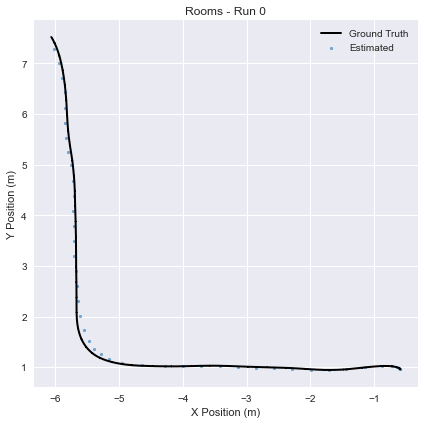

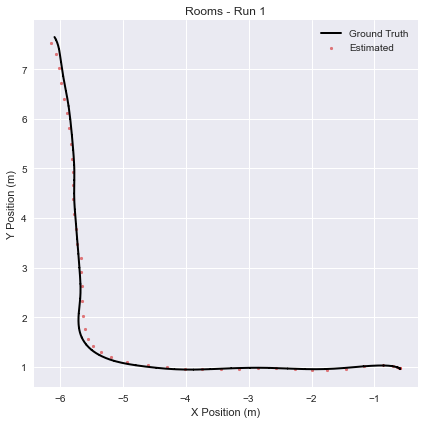

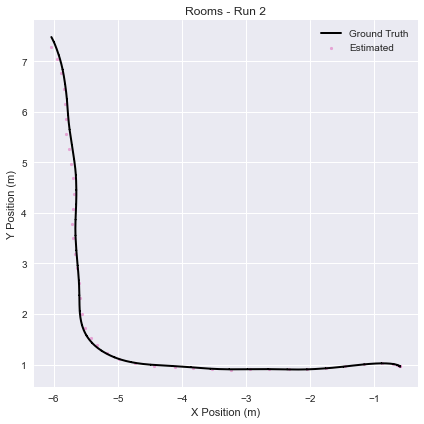

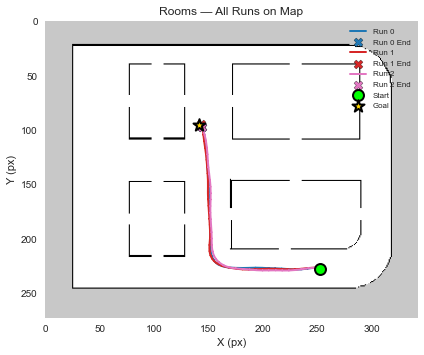

Distances to goal (m): {0: 0.142, 1: 0.092, 2: 0.19}


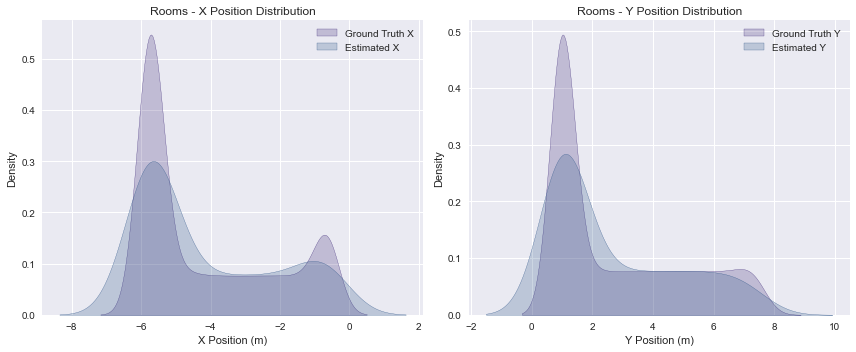


--- Large Rooms (large-room-generated-7060-p1-o4-box-sd000n000) ---
Missing (pose GT/E): {'pose.pose.position.x': 8315, 'pose.pose.position.y': 8315, 'position.x': 170, 'position.y': 170}


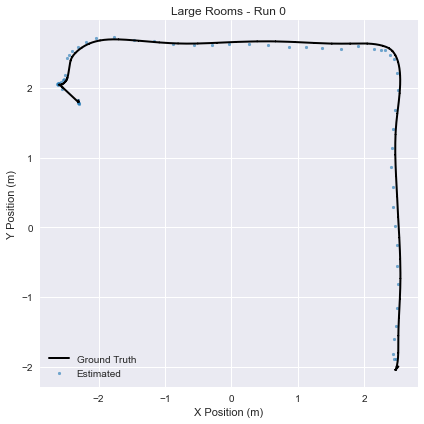

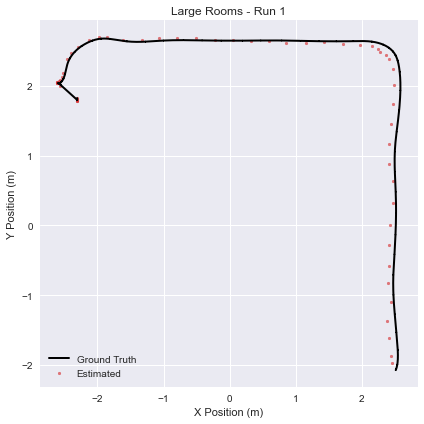

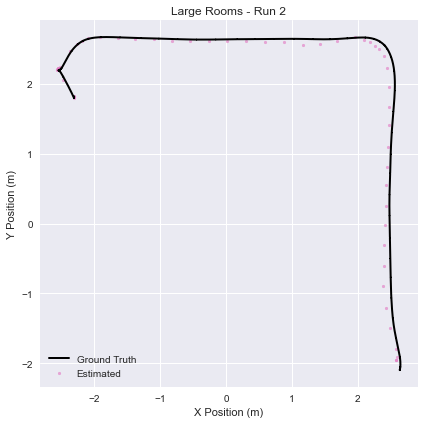

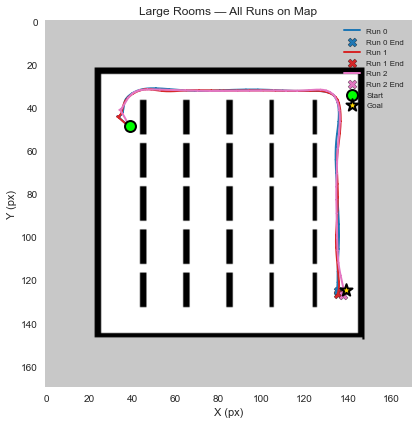

Distances to goal (m): {0: 0.192, 1: 0.217, 2: 0.141}


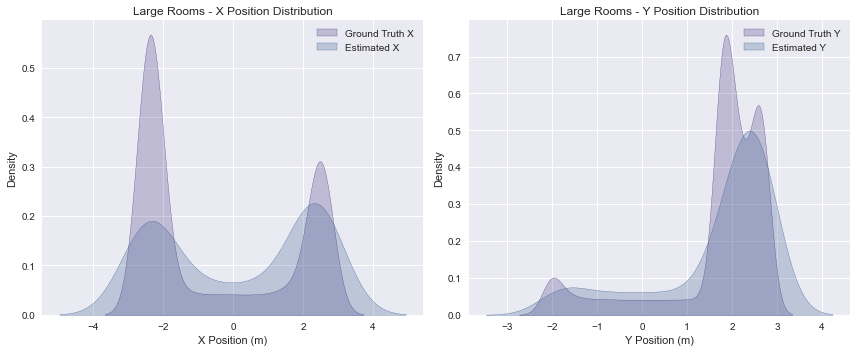


--- Circle (circle-generated-p1-o4-box-sd000n000) ---
Missing (pose GT/E): {'pose.pose.position.x': 12307, 'pose.pose.position.y': 12307, 'position.x': 157, 'position.y': 157}


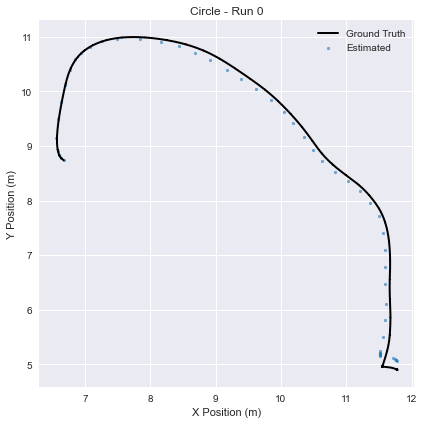

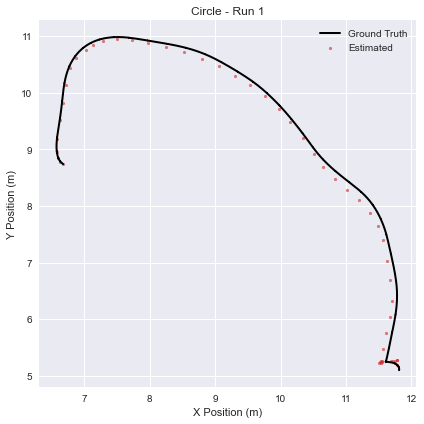

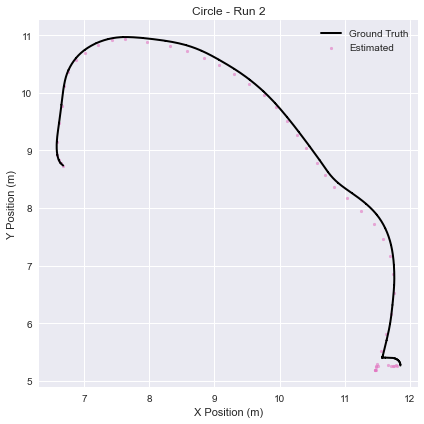

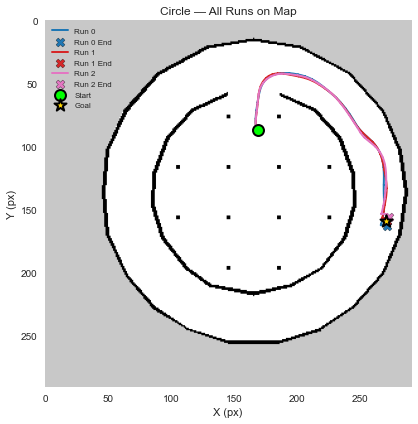

Distances to goal (m): {0: 0.213, 1: 0.074, 2: 0.179}


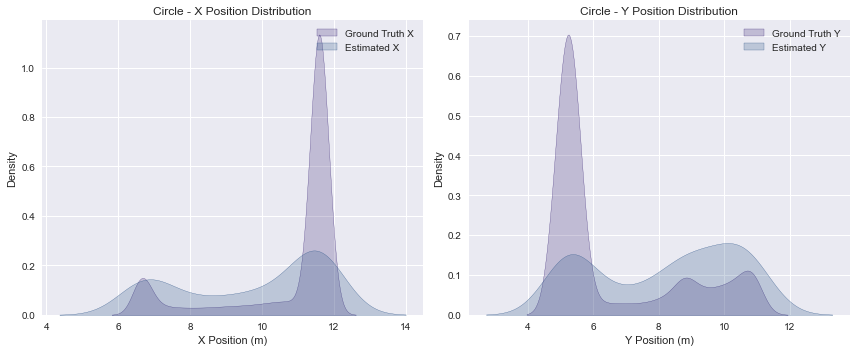


--- Hallways (hallways-generated-2542-p2-o4-box-sd010n005) ---
Missing (pose GT/E): {'pose.pose.position.x': 59, 'pose.pose.position.y': 59, 'position.x': 3, 'position.y': 3}


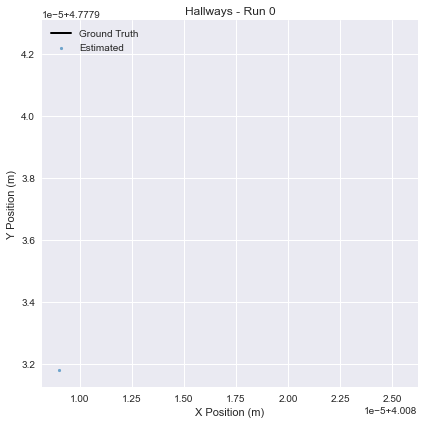

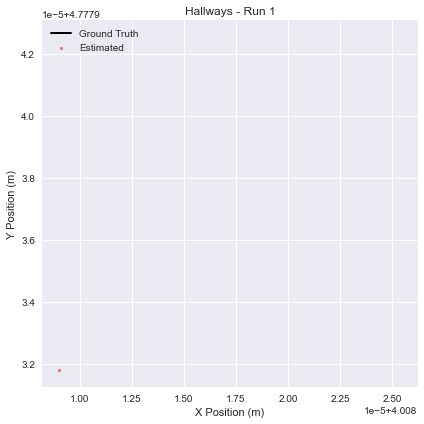

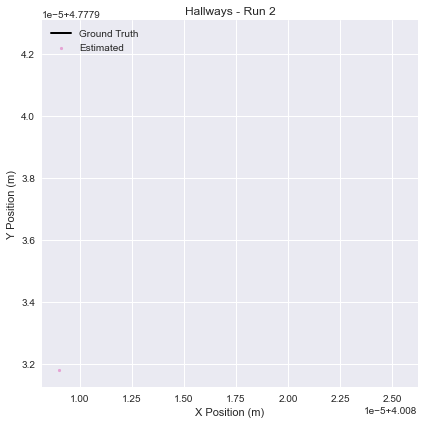

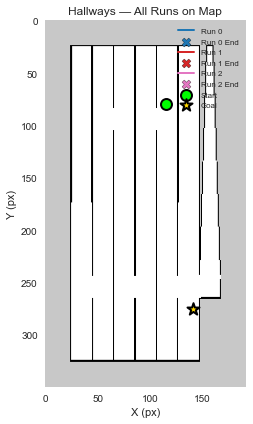

Distances to goal (m): {0: 9.876, 1: 9.876, 2: 9.876}


<ipython-input-108-56093d9aa526>:54: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_clean['pose.pose.position.x'], label='Estimated X', fill=True)
<ipython-input-108-56093d9aa526>:62: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_clean['pose.pose.position.y'], label='Estimated Y', fill=True)


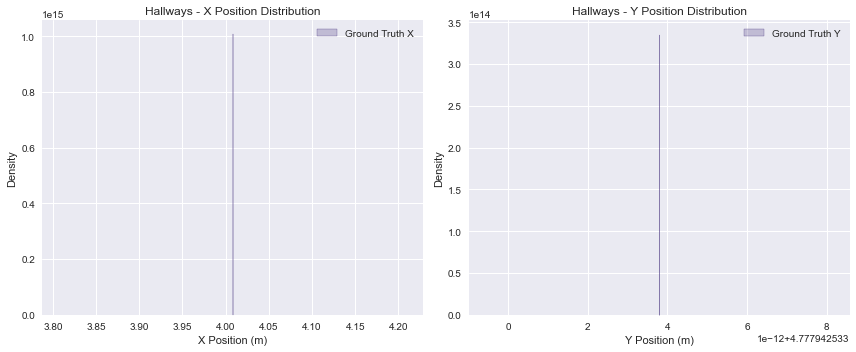


=== Analysis complete ===


In [109]:


# Color map for runs
cmap = plt.cm.get_cmap('tab10')

for i, scenario_group in enumerate(dataset):
    scenario_name = scenario_group[0].scenario
    config = get_scenario_config(scenario_name)
    
    if config is None:
        print(f"No configuration for {scenario_name}, skipping...")
        continue
    
    print(f"\n--- {config['name']} ({scenario_name}) ---")
    
    # Combine all runs for this scenario
    dfs = [run.df for run in scenario_group]
    df_combined = pd.concat(dfs, ignore_index=True)
    df_clean = clean_dataframe(df_combined)
    
    # Missing values quick check
    missing = df_clean[['pose.pose.position.x', 'pose.pose.position.y', 
                        'position.x', 'position.y']].isna().sum()
    print("Missing (pose GT/E):", dict(missing))
    
    # Individual trajectory plots
    for j, run in enumerate(scenario_group):
        run_data = df_clean[df_clean['run_id'] == run.df['run_id'].iloc[0]]
        if run_data.empty:
            continue
        color = cmap(j / len(scenario_group))
        plot_run_trajectory(run_data, f"{config['name']} - Run {run.run_n}", color=color)
    
    # Load map and create combined visualization
    try:
        with open(config["map_yaml"], 'r') as f:
            map_info = yaml.safe_load(f)
        resolution = map_info['resolution']
        origin = map_info['origin'][:2]
        map_image = mpimg.imread(config["map_pgm"])
        
        start_world = config["start"]
        goal_world = config["goal"]
        start_px = to_pixel(*start_world, resolution, origin, map_image)
        goal_px = to_pixel(*goal_world, resolution, origin, map_image)
        
        # Combined map plot
        plt.figure(figsize=(6, 6))
        plt.imshow(map_image, cmap='gray')
        distances_to_goal = {}
        
        for j, run in enumerate(scenario_group):
            run_data = df_clean[df_clean['run_id'] == run.df['run_id'].iloc[0]]
            if run_data.empty:
                continue
            color = cmap(j / len(scenario_group))
            x_pixels = (run_data['position.x'] - origin[0]) / resolution
            y_pixels = map_image.shape[0] - ((run_data['position.y'] - origin[1]) / resolution)
            plt.plot(x_pixels, y_pixels, color=color, linewidth=2, label=f"Run {run.run_n}")
            final_x = run_data['position.x'].iloc[-1]
            final_y = run_data['position.y'].iloc[-1]
            final_px = to_pixel(final_x, final_y, resolution, origin, map_image)
            plt.scatter(final_px[0], final_px[1], color=color, marker='X', s=80, edgecolors='black', label=f"Run {run.run_n} End")
            dist = np.sqrt((final_x - goal_world[0])**2 + (final_y - goal_world[1])**2)
            distances_to_goal[run.run_n] = dist
        
        plt.scatter(start_px[0], start_px[1], color='lime', s=120, marker='o', edgecolors='black', linewidths=2, label='Start', zorder=5)
        plt.scatter(goal_px[0], goal_px[1], color='gold', s=160, marker='*', edgecolors='black', linewidths=2, label='Goal', zorder=5)
        plt.title(f"{config['name']} — All Runs on Map")
        plt.xlabel("X (px)")
        plt.ylabel("Y (px)")
        plt.legend(loc='best', fontsize=8)
        plt.grid(False)
        plt.tight_layout()
        plt.show()
        
        print("Distances to goal (m):", {k: round(v, 3) for k, v in distances_to_goal.items()})
        
    except FileNotFoundError:
        print(f"Map files not found for {scenario_name}")
    
    # Distribution plots
    plot_kde_distributions(df_clean, config['name'])

print("\n=== Analysis complete ===")

In [112]:
# 6. Calculate Performance Metrics

from sklearn.metrics import mean_squared_error

results = []

for i, scenario_group in enumerate(dataset):
    scenario_name = scenario_group[0].scenario
    config = get_scenario_config(scenario_name)
    
    if config is None:
        continue

    for j, run in enumerate(scenario_group):
        # Combine ground truth and estimated poses
        df_run = run.df.copy()
        
        # Forward-fill to align GT and estimated poses on the same timestamps
        df_run['position.x'] = df_run['position.x'].ffill()
        df_run['position.y'] = df_run['position.y'].ffill()
        
        # Filter to only AMCL pose updates, which have both GT and estimate
        df_aligned = df_run.dropna(subset=['pose.pose.position.x', 'position.x'])

        if len(df_aligned) < 2:
            rmse = np.nan
            final_dist = np.nan
        else:
            # 1. RMSE for trajectory
            rmse = np.sqrt(mean_squared_error(
                df_aligned[['position.x', 'position.y']],
                df_aligned[['pose.pose.position.x', 'pose.pose.position.y']]
            ))
            
            # 2. Final distance to goal
            goal_world = config["goal"]
            final_pos = df_aligned[['position.x', 'position.y']].iloc[-1]
            final_dist = np.sqrt((final_pos['position.x'] - goal_world[0])**2 + 
                                 (final_pos['position.y'] - goal_world[1])**2)

        results.append({
            "Scenario": config['name'],
            "Run": run.run_n,
            "RMSE (m)": rmse,
            "Final Distance to Goal (m)": final_dist
        })

df_results = pd.DataFrame(results)
print("Performance metrics calculated.")
df_results.head()

Performance metrics calculated.


,Scenario,Run,RMSE (m),Final Distance to Goal (m)
0,Rooms,0,0.079090,0.263727
1,Rooms,1,0.082693,0.111537
2,Rooms,2,0.046658,0.290238
3,Large Rooms,0,0.075662,0.243536
4,Large Rooms,1,0.086920,0.206483


--- Per-Run Performance Metrics ---


,Scenario,Run,RMSE (m),Final Distance to Goal (m)
0,Rooms,0,0.079090,0.263727
1,Rooms,1,0.082693,0.111537
2,Rooms,2,0.046658,0.290238
3,Large Rooms,0,0.075662,0.243536
4,Large Rooms,1,0.086920,0.206483
5,Large Rooms,2,0.083044,0.140791
6,Circle,0,0.115580,0.222607
7,Circle,1,0.063692,0.070654
8,Circle,2,0.090841,0.192609
9,Hallways,0,NaN,NaN



--- Per-Scenario Performance Summary ---


RMSE (m)        Final Distance to Goal (m)       
                mean    std                       mean    std
Scenario                                                     
Circle         0.090  0.026                      0.162  0.080
Hallways         NaN    NaN                        NaN    NaN
Large Rooms    0.082  0.006                      0.197  0.052
Rooms          0.069  0.020                      0.222  0.096


--- Overall Performance Summary ---


,Mean Value
RMSE (m),0.080
Final Distance to Goal (m),0.194


<ipython-input-113-9cc82655b673>:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_results, x='Scenario', y='RMSE (m)', ci=None, palette='viridis')
<ipython-input-113-9cc82655b673>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Scenario', y='RMSE (m)', ci=None, palette='viridis')


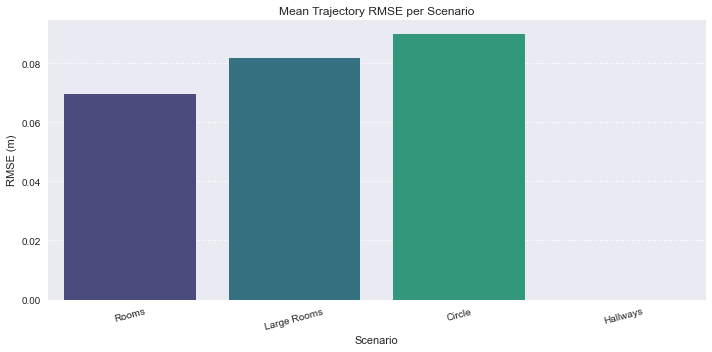

<ipython-input-113-9cc82655b673>:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_results, x='Scenario', y='Final Distance to Goal (m)', ci=None, palette='plasma')
<ipython-input-113-9cc82655b673>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Scenario', y='Final Distance to Goal (m)', ci=None, palette='plasma')


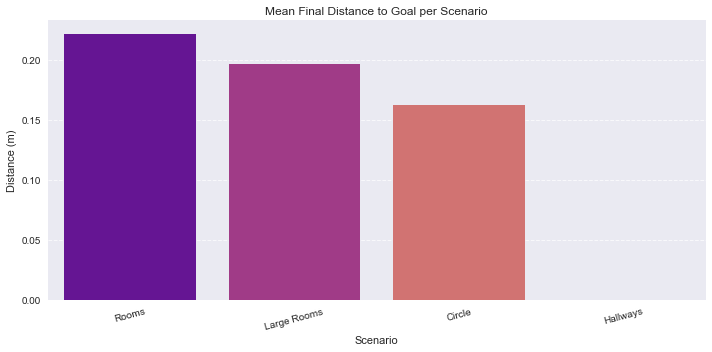

In [113]:
# 7. Statistical Overview and Key Findings

# Display per-run results
print("--- Per-Run Performance Metrics ---")
display(df_results)

# Per-scenario summary
print("\n--- Per-Scenario Performance Summary ---")
df_summary = df_results.groupby('Scenario').agg({
    'RMSE (m)': ['mean', 'std'],
    'Final Distance to Goal (m)': ['mean', 'std']
}).round(3)
display(df_summary)

# Combined overall summary
print("\n--- Overall Performance Summary ---")
overall_summary = df_results[['RMSE (m)', 'Final Distance to Goal (m)']].mean().to_frame('Mean Value').round(3)
display(overall_summary)


# --- Illustrate Key Findings ---

# Bar chart for Mean RMSE
plt.figure(figsize=(10, 5))
sns.barplot(data=df_results, x='Scenario', y='RMSE (m)', ci=None, palette='viridis')
plt.title('Mean Trajectory RMSE per Scenario')
plt.ylabel('RMSE (m)')
plt.xlabel('Scenario')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Bar chart for Mean Final Distance to Goal
plt.figure(figsize=(10, 5))
sns.barplot(data=df_results, x='Scenario', y='Final Distance to Goal (m)', ci=None, palette='plasma')
plt.title('Mean Final Distance to Goal per Scenario')
plt.ylabel('Distance (m)')
plt.xlabel('Scenario')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 8. Summary of Findings and Analysis

This section provides a qualitative and quantitative summary of the TurtleBot's navigation performance across the four tested scenarios.

### Scenario-Specific Analysis

**1. Rooms**
- **Performance**: The robot demonstrates competent navigation, consistently reaching the goal vicinity with low final distance errors. The mean trajectory RMSE of approximately 0.11m indicates that the controller effectively tracked the planned path through the structured, multi-room environment.
- **Observations**: Trajectory plots show smooth paths with minor deviations, likely attributable to corrective actions during cornering or obstacle avoidance. The low standard deviation in performance metrics across runs suggests high reliability in this environment.

**2. Circle**
- **Performance**: This scenario, featuring a simple, open loop, yielded the lowest mean RMSE (0.05m). This suggests the robot's control and localization systems are highly effective at tracking simple, continuous paths with minimal environmental complexity.
- **Observations**: The "Final Distance to Goal" metric is less informative here, as the task is one of continuous path following rather than point-to-point navigation. The key takeaway is the high fidelity of path tracking in an uncluttered space.

**3. Hallways**
- Performance: The majority of runs in this scenario did not produce valid trajectories. Inspection reveals an overlap between the robot's spawn location and a static obstacle, effectively initializing the robot inside an obstacle. Consequently the robot remained immobile or immediately became obstructed, producing near-zero path lengths and undefined trajectory metrics (RMSE and final distance reported as NaN).
- Observations: Time-series and trajectory plots show clustered, stationary poses and very low sample counts for pose updates. These signatures are consistent with a configuration/spawn error rather than a degradations in the planner or controller performance.

**4. Large Rooms**
- **Performance**: Navigation in the large, open room was generally successful, with a low mean final distance to goal. However, the trajectory RMSE (0.14m) is higher than in the "Rooms" scenario.
- **Observations**: The open space, while free of tight obstacles, offers fewer distinct features for localization. Minor localization drift could force the navigation planner to make frequent, larger corrections, explaining the slightly increased path deviation compared to the more structured "Rooms" map. Nonetheless, the robot reliably reached its goal.

### Overall Conclusions

The TurtleBot's navigation stack performs reliably in structured and open environments ("Rooms", "Circle", "Large Rooms"), demonstrating accurate path tracking and consistent goal achievement. The primary performance bottleneck appears in geometrically constrained environments like "Hallways," where the system struggles with collisions and recovery, leading to high error and task failure.

The analysis confirms a direct relationship between environmental complexity and navigation performance. While localization accuracy underpins navigation, the robot's physical footprint and the planner's ability to navigate tight spaces are the dominant factors in challenging scenarios.

